In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
!pip install awscli

In [ ]:
!aws s3 ls --no-sign-request s3://cse-cic-ids2018/

In [ ]:
!aws s3 ls --no-sign-request \
"s3://cse-cic-ids2018/Processed Traffic Data for ML Algorithms/"

In [ ]:
!mkdir -p /kaggle/working/CIC_IDS2018

!aws s3 sync \
    --no-sign-request \
    "s3://cse-cic-ids2018/Processed Traffic Data for ML Algorithms/" \
    /kaggle/working/CIC_IDS2018

In [ ]:
!ls -lh /kaggle/working/CIC_IDS2018

In [ ]:
import os
import pandas as pd

data_dir = "/kaggle/working/CIC_IDS2018"

csv_files = sorted(
    [
        os.path.join(data_dir, f)
        for f in os.listdir(data_dir)
        if f.endswith(".csv")
    ]
)

print(f"Found {len(csv_files)} CSV files:")
for f in csv_files:
    print(os.path.basename(f))

summary = []

for file in csv_files:

    df = pd.read_csv(file, nrows=5)

    summary.append({
        "File": os.path.basename(file),
        "Columns": len(df.columns),
        "Rows (Sample)": len(df),
        "Label Exists": "Label" in df.columns,
        "Timestamp Exists": "Timestamp" in df.columns
    })

summary_df = pd.DataFrame(summary)

summary_df

In [ ]:
summary = []

for file in csv_files:

    df = pd.read_csv(file, nrows=5)

    summary.append({
        "File": os.path.basename(file),
        "Columns": len(df.columns),
        "Rows (Sample)": len(df),
        "Label Exists": "Label" in df.columns,
        "Timestamp Exists": "Timestamp" in df.columns
    })

summary_df = pd.DataFrame(summary)

summary_df

In [ ]:
first_columns = pd.read_csv(csv_files[0], nrows=0).columns.tolist()

all_same = True

for file in csv_files[1:]:

    cols = pd.read_csv(file, nrows=0).columns.tolist()

    if cols != first_columns:

        print(f"Mismatch found in {os.path.basename(file)}")
        all_same = False

print("All files have identical columns:", all_same)

In [ ]:
cols_ref = pd.read_csv(csv_files[0], nrows=0).columns.tolist()
cols_bad = pd.read_csv(
    "/kaggle/working/CIC_IDS2018/Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv",
    nrows=0
).columns.tolist()

print("Reference columns:", len(cols_ref))
print("Tuesday columns :", len(cols_bad))

In [ ]:
print("Missing from Tuesday:")
print(set(cols_ref) - set(cols_bad))

print("\nExtra in Tuesday:")
print(set(cols_bad) - set(cols_ref))

In [ ]:
common = set(cols_ref).intersection(cols_bad)

print(len(common))

In [ ]:
df_tuesday = pd.read_csv(
    "/kaggle/working/CIC_IDS2018/Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv",
    nrows=5
)

print(df_tuesday.columns[:10].tolist())

In [ ]:
df = pd.read_csv(
    "/kaggle/working/CIC_IDS2018/Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv",
    usecols=["Label"]
)

print(df["Label"].value_counts())

In [ ]:
for file in csv_files:

    temp = pd.read_csv(file, nrows=0)

    temp.drop(
        columns=["Flow ID", "Src IP", "Src Port", "Dst IP"],
        errors="ignore",
        inplace=True
    )

    print(os.path.basename(file), len(temp.columns))

Merge

In [ ]:
import os
import pandas as pd

data_dir = "/kaggle/working/CIC_IDS2018"

csv_files = sorted(
    [
        os.path.join(data_dir, f)
        for f in os.listdir(data_dir)
        if f.endswith(".csv")
    ]
)

print(f"Found {len(csv_files)} CSV files")
for f in csv_files:
    print(os.path.basename(f))

In [ ]:
import os
import gc
import pandas as pd

output_file = "/kaggle/working/CIC_IDS2018_Merged_Official.csv"

first_file = True

for i, file in enumerate(csv_files, 1):

    print(f"[{i}/{len(csv_files)}] Processing {os.path.basename(file)}")

    df = pd.read_csv(file, low_memory=False)

    # Remove extra columns from Tuesday
    df.drop(
        columns=["Flow ID", "Src IP", "Src Port", "Dst IP"],
        errors="ignore",
        inplace=True
    )

    df.to_csv(
        output_file,
        mode="w" if first_file else "a",
        header=first_file,
        index=False
    )

    first_file = False

    # Free RAM after each file
    del df
    gc.collect()

print("\n✅ Merge completed successfully!")

In [ ]:
import shutil
import os

folder = "/kaggle/working/CIC_IDS2018"

if os.path.exists(folder):
    shutil.rmtree(folder)
    print("✅ Folder deleted successfully.")
else:
    print("Folder not found.")

print("\nRemaining files:")
print(os.listdir("/kaggle/working"))

In [ ]:
import os

print(os.listdir("/kaggle/working"))

Chunking

In [1]:
import pandas as pd

DATA_PATH = "/kaggle/input/datasets/manvidhamija/cicidsmerged/CIC_IDS2018_Merged_Official.csv"
CHUNK_SIZE = 500_000

reader = pd.read_csv(
    DATA_PATH,
    chunksize=CHUNK_SIZE,
    low_memory=False
)

In [3]:
first_chunk = next(reader)

print(first_chunk.shape)

first_chunk.head()

(500000, 80)


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,443,6,02/03/2018 08:47:38,141385,9,7,553,3773.0,202,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
1,49684,6,02/03/2018 08:47:38,281,2,1,38,0.0,38,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
2,443,6,02/03/2018 08:47:40,279824,11,15,1086,10527.0,385,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
3,443,6,02/03/2018 08:47:40,132,2,0,0,0.0,0,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
4,443,6,02/03/2018 08:47:41,274016,9,13,1285,6141.0,517,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign


In [4]:
first_chunk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 80 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Dst Port           500000 non-null  int64  
 1   Protocol           500000 non-null  int64  
 2   Timestamp          500000 non-null  object 
 3   Flow Duration      500000 non-null  int64  
 4   Tot Fwd Pkts       500000 non-null  int64  
 5   Tot Bwd Pkts       500000 non-null  int64  
 6   TotLen Fwd Pkts    500000 non-null  int64  
 7   TotLen Bwd Pkts    500000 non-null  float64
 8   Fwd Pkt Len Max    500000 non-null  int64  
 9   Fwd Pkt Len Min    500000 non-null  int64  
 10  Fwd Pkt Len Mean   500000 non-null  float64
 11  Fwd Pkt Len Std    500000 non-null  float64
 12  Bwd Pkt Len Max    500000 non-null  int64  
 13  Bwd Pkt Len Min    500000 non-null  int64  
 14  Bwd Pkt Len Mean   500000 non-null  float64
 15  Bwd Pkt Len Std    500000 non-null  float64
 16  Fl

In [5]:
first_chunk.memory_usage(deep=True).sum() / 1024**2

np.float64(355.3786840438843)

In [7]:
from collections import Counter

In [8]:
total_rows = 0

duplicate_rows = 0

label_counter = Counter()

nan_counts = None

inf_counts = None

timestamp_min = None

timestamp_max = None

In [9]:
reader = pd.read_csv(
    DATA_PATH,
    chunksize=CHUNK_SIZE,
    low_memory=False
)

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [18]:
for chunk_no, chunk in enumerate(reader, start=1):

    print(
        f"Chunk {chunk_no} completed | "
        f"Rows processed: {total_rows:,}"
    )

    # --------------------------------------------------
    # Dataset Size
    # --------------------------------------------------

    total_rows += len(chunk)

    # --------------------------------------------------
    # Labels
    # --------------------------------------------------

    label_counter.update(chunk["Label"])

    # --------------------------------------------------
    # Missing Values
    # --------------------------------------------------

    if nan_counts is None:
        nan_counts = chunk.isna().sum()
    else:
        nan_counts += chunk.isna().sum()

    # --------------------------------------------------
    # Infinite Values
    # --------------------------------------------------

    numeric = chunk.select_dtypes(include=np.number)

    current_inf = pd.Series(
        np.isinf(numeric).sum(),
        index=numeric.columns
    )

    if inf_counts is None:
        inf_counts = current_inf
    else:
        inf_counts += current_inf

    # --------------------------------------------------
    # Duplicate Rows (within chunk)
    # --------------------------------------------------

    duplicate_rows += chunk.duplicated().sum()

    # --------------------------------------------------
    # Timestamp
    # --------------------------------------------------

    chunk["Timestamp"] = pd.to_datetime(
        chunk["Timestamp"],
        format="%d/%m/%Y %H:%M:%S",
        errors="coerce"
    )

    current_min = chunk["Timestamp"].min()
    current_max = chunk["Timestamp"].max()

    if timestamp_min is None:
        timestamp_min = current_min
    else:
        timestamp_min = min(timestamp_min, current_min)

    if timestamp_max is None:
        timestamp_max = current_max
    else:
        timestamp_max = max(timestamp_max, current_max)

    del chunk
    gc.collect()

Chunk 1 completed | Rows processed: 3,500,000
Chunk 2 completed | Rows processed: 4,000,000
Chunk 3 completed | Rows processed: 4,500,000
Chunk 4 completed | Rows processed: 5,000,000
Chunk 5 completed | Rows processed: 5,500,000
Chunk 6 completed | Rows processed: 6,000,000
Chunk 7 completed | Rows processed: 6,500,000
Chunk 8 completed | Rows processed: 7,000,000
Chunk 9 completed | Rows processed: 7,500,000
Chunk 10 completed | Rows processed: 8,000,000
Chunk 11 completed | Rows processed: 8,500,000
Chunk 12 completed | Rows processed: 9,000,000
Chunk 13 completed | Rows processed: 9,500,000
Chunk 14 completed | Rows processed: 10,000,000
Chunk 15 completed | Rows processed: 10,500,000
Chunk 16 completed | Rows processed: 11,000,000
Chunk 17 completed | Rows processed: 11,500,000
Chunk 18 completed | Rows processed: 12,000,000
Chunk 19 completed | Rows processed: 12,500,000
Chunk 20 completed | Rows processed: 13,000,000
Chunk 21 completed | Rows processed: 13,500,000
Chunk 22 compl

In [19]:
class_df = (
    pd.DataFrame.from_dict(
        label_counter,
        orient="index",
        columns=["Count"]
    )
    .sort_values("Count", ascending=False)
)

display(class_df)

,Count
Benign,12838818
DDOS attack-HOIC,686012
DoS attacks-Hulk,461912
Bot,286191
DDoS attacks-LOIC-HTTP,222081
FTP-BruteForce,193360
SSH-Bruteforce,187589
Infilteration,161934
DoS attacks-SlowHTTPTest,139890
DoS attacks-GoldenEye,41508


In [20]:
df_sample = pd.read_csv(
    DATA_PATH,
    chunksize=500000,
    low_memory=False
)

for chunk in df_sample:
    bad = chunk[chunk["Label"] == "Label"]

    if len(bad) > 0:
        display(bad.head())
        break

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,Bwd Pkt Len Max,Bwd Pkt Len Min,Bwd Pkt Len Mean,Bwd Pkt Len Std,Flow Byts/s,Flow Pkts/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Tot,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Tot,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Len,Bwd Header Len,Fwd Pkts/s,Bwd Pkts/s,Pkt Len Min,Pkt Len Max,Pkt Len Mean,Pkt Len Std,Pkt Len Var,FIN Flag Cnt,SYN Flag Cnt,RST Flag Cnt,PSH Flag Cnt,ACK Flag Cnt,URG Flag Cnt,CWE Flag Count,ECE Flag Cnt,Down/Up Ratio,Pkt Size Avg,Fwd Seg Size Avg,Bwd Seg Size Avg,Fwd Byts/b Avg,Fwd Pkts/b Avg,Fwd Blk Rate Avg,Bwd Byts/b Avg,Bwd Pkts/b Avg,Bwd Blk Rate Avg,Subflow Fwd Pkts,Subflow Fwd Byts,Subflow Bwd Pkts,Subflow Bwd Byts,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
2048574,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,Bwd Pkt Len Max,Bwd Pkt Len Min,Bwd Pkt Len Mean,Bwd Pkt Len Std,Flow Byts/s,Flow Pkts/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Tot,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Tot,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Len,Bwd Header Len,Fwd Pkts/s,Bwd Pkts/s,Pkt Len Min,Pkt Len Max,Pkt Len Mean,Pkt Len Std,Pkt Len Var,FIN Flag Cnt,SYN Flag Cnt,RST Flag Cnt,PSH Flag Cnt,ACK Flag Cnt,URG Flag Cnt,CWE Flag Count,ECE Flag Cnt,Down/Up Ratio,Pkt Size Avg,Fwd Seg Size Avg,Bwd Seg Size Avg,Fwd Byts/b Avg,Fwd Pkts/b Avg,Fwd Blk Rate Avg,Bwd Byts/b Avg,Bwd Pkts/b Avg,Bwd Blk Rate Avg,Subflow Fwd Pkts,Subflow Fwd Byts,Subflow Bwd Pkts,Subflow Bwd Byts,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label


In [21]:
header_rows = (chunk["Label"] == "Label").sum()

print(f"Header rows removed: {header_rows}")

chunk = chunk[chunk["Label"] != "Label"]

Header rows removed: 1


In [22]:
print(chunk["Label"].unique())

['Benign' 'DoS attacks-Hulk' 'DoS attacks-SlowHTTPTest' 'Brute Force -Web'
 'Brute Force -XSS' 'SQL Injection']


In [23]:
def clean_chunk(chunk):

    # Remove repeated CSV headers
    chunk = chunk[chunk["Label"] != "Label"].copy()

    return chunk

In [ ]:
cleaning

In [24]:
import os

OUTPUT_DIR = "/kaggle/working/CIC_IDS2018_Cleaned"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Output folder created:", OUTPUT_DIR)

Output folder created: /kaggle/working/CIC_IDS2018_Cleaned


In [25]:
import numpy as np
import pandas as pd

def clean_chunk(chunk):

    # -----------------------------------------
    # 1. Remove repeated header rows
    # -----------------------------------------
    chunk = chunk[chunk["Label"] != "Label"].copy()

    # -----------------------------------------
    # 2. Replace Infinity with NaN
    # -----------------------------------------
    chunk.replace([np.inf, -np.inf], np.nan, inplace=True)

    # -----------------------------------------
    # 3. Convert Timestamp
    # -----------------------------------------
    chunk["Timestamp"] = pd.to_datetime(
        chunk["Timestamp"],
        format="%d/%m/%Y %H:%M:%S",
        errors="coerce"
    )

    return chunk

In [27]:
import os

print(os.path.exists(OUTPUT_DIR))
print(os.listdir("/kaggle/working"))

True
['CIC_IDS2018_Cleaned', '.virtual_documents']


In [28]:
reader = pd.read_csv(DATA_PATH, chunksize=500000, low_memory=False)

chunk = next(reader)

chunk = clean_chunk(chunk)

print(chunk.shape)

chunk.to_csv(
    f"{OUTPUT_DIR}/test_chunk.csv",
    index=False
)

print(os.listdir(OUTPUT_DIR))

(500000, 80)
['test_chunk.csv']


In [29]:
for chunk_no, chunk in enumerate(reader, start=1):

    try:
        print(f"Cleaning Chunk {chunk_no}")

        chunk = clean_chunk(chunk)

        print(chunk.shape)

        chunk.to_csv(
            f"{OUTPUT_DIR}/clean_chunk_{chunk_no}.csv",
            index=False
        )

    except Exception as e:
        print(f"Error in chunk {chunk_no}: {e}")
        break

Cleaning Chunk 1
(500000, 80)
Cleaning Chunk 2
(500000, 80)
Cleaning Chunk 3
(500000, 80)
Cleaning Chunk 4
(499999, 80)
Cleaning Chunk 5
(500000, 80)
Cleaning Chunk 6
(500000, 80)
Cleaning Chunk 7
(500000, 80)
Cleaning Chunk 8
(500000, 80)
Cleaning Chunk 9
(500000, 80)
Cleaning Chunk 10
(500000, 80)
Cleaning Chunk 11
(500000, 80)
Cleaning Chunk 12
(500000, 80)
Cleaning Chunk 13
(500000, 80)
Cleaning Chunk 14
(500000, 80)
Cleaning Chunk 15
(500000, 80)
Cleaning Chunk 16
(500000, 80)
Cleaning Chunk 17
(500000, 80)
Cleaning Chunk 18
(500000, 80)
Cleaning Chunk 19
(500000, 80)
Cleaning Chunk 20
(500000, 80)
Cleaning Chunk 21
(500000, 80)
Cleaning Chunk 22
(499975, 80)
Cleaning Chunk 23
(500000, 80)
Cleaning Chunk 24
(500000, 80)
Cleaning Chunk 25
(500000, 80)
Cleaning Chunk 26
(500000, 80)
Cleaning Chunk 27
(500000, 80)
Cleaning Chunk 28
(500000, 80)
Cleaning Chunk 29
(500000, 80)
Cleaning Chunk 30
(500000, 80)
Cleaning Chunk 31
(499977, 80)
Cleaning Chunk 32
(232992, 80)


In [30]:
import os

files = sorted(os.listdir(OUTPUT_DIR))

print(f"Total cleaned chunks: {len(files)}")
print(files[:5])

Total cleaned chunks: 33
['clean_chunk_1.csv', 'clean_chunk_10.csv', 'clean_chunk_11.csv', 'clean_chunk_12.csv', 'clean_chunk_13.csv']


In [31]:
import os

test_file = "/kaggle/working/CIC_IDS2018_Cleaned/test_chunk.csv"

if os.path.exists(test_file):
    os.remove(test_file)
    print("✅ test_chunk.csv deleted")
else:
    print("test_chunk.csv not found")

✅ test_chunk.csv deleted


In [32]:
clean_df = pd.read_csv(
    "/kaggle/working/CIC_IDS2018_Cleaned/clean_chunk_1.csv"
)

print(clean_df.shape)

(500000, 80)


In [33]:
print(clean_df["Label"].unique())

['Benign']


In [34]:
clean_df["Timestamp"] = pd.to_datetime(
    clean_df["Timestamp"],
    errors="coerce"
)

print(clean_df["Timestamp"].head())

0   2018-03-02 04:41:43
1   2018-03-02 10:07:42
2   2018-03-02 04:33:26
3   2018-03-02 04:42:00
4   2018-03-02 04:42:00
Name: Timestamp, dtype: datetime64[ns]


In [35]:
clean_df.isnull().sum().sort_values(ascending=False).head(10)

Flow Pkts/s        2637
Flow Byts/s        2637
Dst Port              0
Protocol              0
Tot Fwd Pkts          0
Tot Bwd Pkts          0
Timestamp             0
Flow Duration         0
Fwd Pkt Len Max       0
Fwd Pkt Len Min       0
dtype: int64

In [36]:
import numpy as np

numeric = clean_df.select_dtypes(include=np.number)

print(np.isinf(numeric).sum().sum())

0


In [37]:
zero_duration = clean_df["Flow Duration"] == 0

print("Zero-duration flows:", zero_duration.sum())

print(
    clean_df.loc[
        zero_duration,
        ["Flow Duration", "Flow Byts/s", "Flow Pkts/s", "Label"]
    ].head(20)
)

Zero-duration flows: 2637
      Flow Duration  Flow Byts/s  Flow Pkts/s   Label
81                0          NaN          NaN  Benign
798               0          NaN          NaN  Benign
833               0          NaN          NaN  Benign
1383              0          NaN          NaN  Benign
1695              0          NaN          NaN  Benign
2015              0          NaN          NaN  Benign
2174              0          NaN          NaN  Benign
3515              0          NaN          NaN  Benign
3666              0          NaN          NaN  Benign
3977              0          NaN          NaN  Benign
4677              0          NaN          NaN  Benign
4777              0          NaN          NaN  Benign
5309              0          NaN          NaN  Benign
5437              0          NaN          NaN  Benign
5505              0          NaN          NaN  Benign
5935              0          NaN          NaN  Benign
6347              0          NaN          NaN  Benign
66

EDA

In [42]:
import os

CLEANED_DIR = "/kaggle/working/CIC_IDS2018_Cleaned"

chunk_files = sorted(
    [
        os.path.join(CLEANED_DIR, file)
        for file in os.listdir(CLEANED_DIR)
        if file.endswith(".csv")
    ]
)

print("Total Chunks :", len(chunk_files))

Total Chunks : 32


In [43]:
total_rows = 0

for file in chunk_files:

    df = pd.read_csv(file)

    total_rows += len(df)

print(f"Total Rows : {total_rows:,}")

Total Rows : 15,732,943


In [44]:
from collections import Counter

label_counter = Counter()

for file in chunk_files:

    df = pd.read_csv(
        file,
        usecols=["Label"]
    )

    label_counter.update(df["Label"])

In [45]:
class_df = (
    pd.DataFrame.from_dict(
        label_counter,
        orient="index",
        columns=["Count"]
    )
    .sort_values(
        "Count",
        ascending=False
    )
)

display(class_df)

,Count
Benign,13270899
DDOS attack-HOIC,686012
DDoS attacks-LOIC-HTTP,576191
DoS attacks-Hulk,461912
FTP-BruteForce,193360
SSH-Bruteforce,187589
Infilteration,161934
DoS attacks-SlowHTTPTest,139890
DoS attacks-GoldenEye,41508
DoS attacks-Slowloris,10990


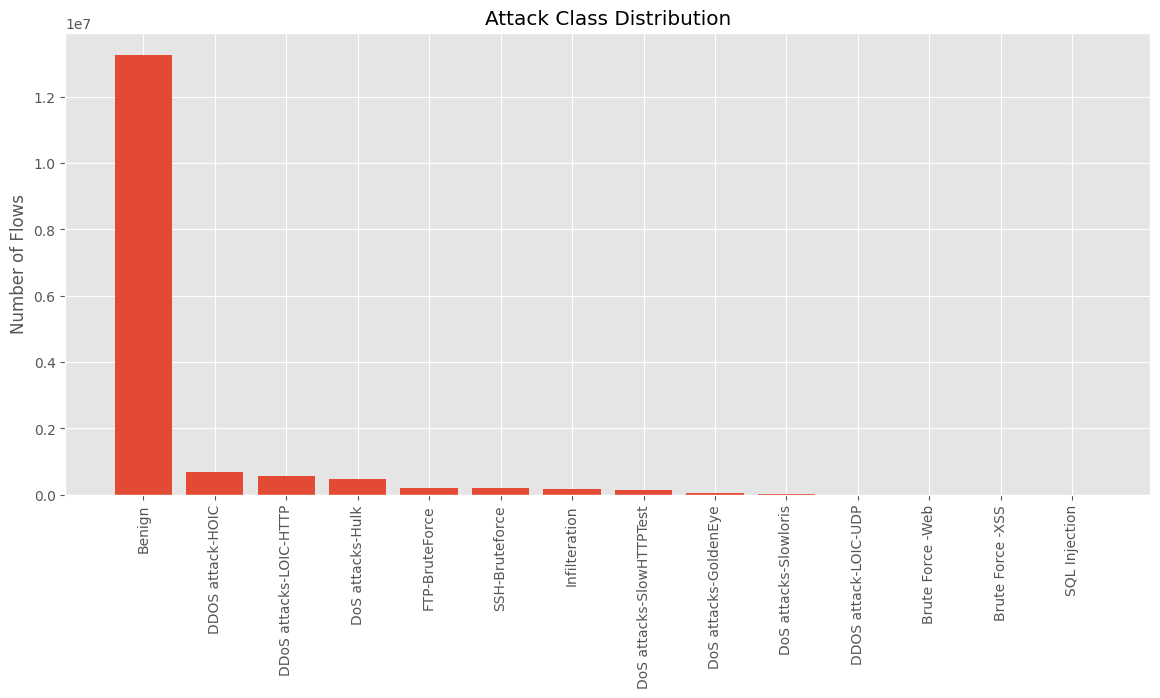

In [46]:
plt.figure(figsize=(14,6))

plt.bar(
    class_df.index,
    class_df["Count"]
)

plt.xticks(rotation=90)

plt.ylabel("Number of Flows")

plt.title("Attack Class Distribution")

plt.show()

In [47]:
majority = class_df["Count"].max()
minority = class_df["Count"].min()

print(
    "Imbalance Ratio :",
    round(majority/minority)
)

Imbalance Ratio : 152539


TEMPORAL ANALYSIS

In [49]:
attack_time = []

for file in chunk_files:

    df = pd.read_csv(
        file,
        usecols=["Timestamp","Label"]
    )

    df["Timestamp"] = pd.to_datetime(df["Timestamp"])

    attack_time.append(df)

attack_df = pd.concat(attack_time)

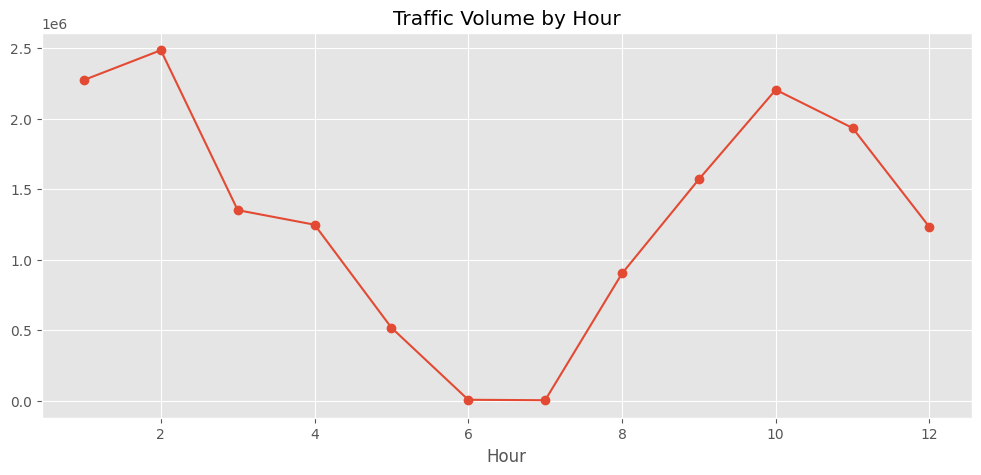

In [50]:
attack_df["Hour"] = attack_df["Timestamp"].dt.hour

hourly = attack_df.groupby("Hour").size()

hourly.plot(
    figsize=(12,5),
    marker="o"
)

plt.title("Traffic Volume by Hour")
plt.show()

/tmp/ipykernel_58/2364161336.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .dt.floor("H")
/tmp/ipykernel_58/2364161336.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  attack_only["Hour"] = (


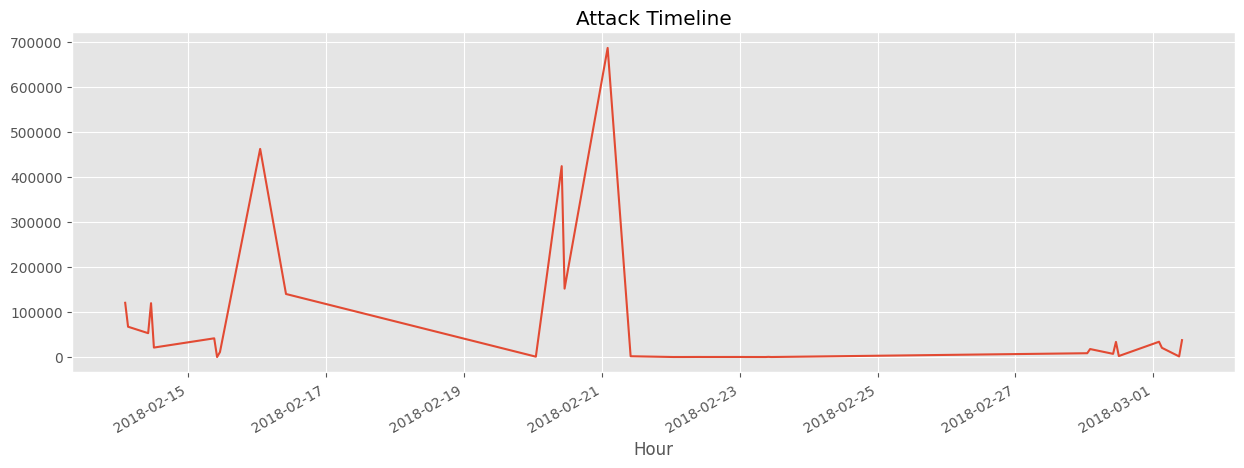

In [51]:
attack_only = attack_df[
    attack_df["Label"] != "Benign"
]

attack_only["Hour"] = (
    attack_only["Timestamp"]
    .dt.floor("H")
)

timeline = (
    attack_only
    .groupby("Hour")
    .size()
)

timeline.plot(figsize=(15,5))

plt.title("Attack Timeline")

plt.show()

In [54]:
sample = pd.read_csv(chunk_files[0])

sample["Timestamp"] = pd.to_datetime(
    sample["Timestamp"]
)

sample = sample.sort_values("Timestamp")

In [55]:
sample["TimeGap"] = (
    sample["Timestamp"]
    .diff()
    .dt.total_seconds()
)

sample["TimeGap"].describe()

count    499999.000000
mean          0.086398
std          16.654070
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       11775.000000
Name: TimeGap, dtype: float64

In [56]:
sample["TimeGap"].value_counts().head(20)

TimeGap
0.0        468651
1.0         31271
2.0            75
11775.0         1
3.0             1
Name: count, dtype: int64

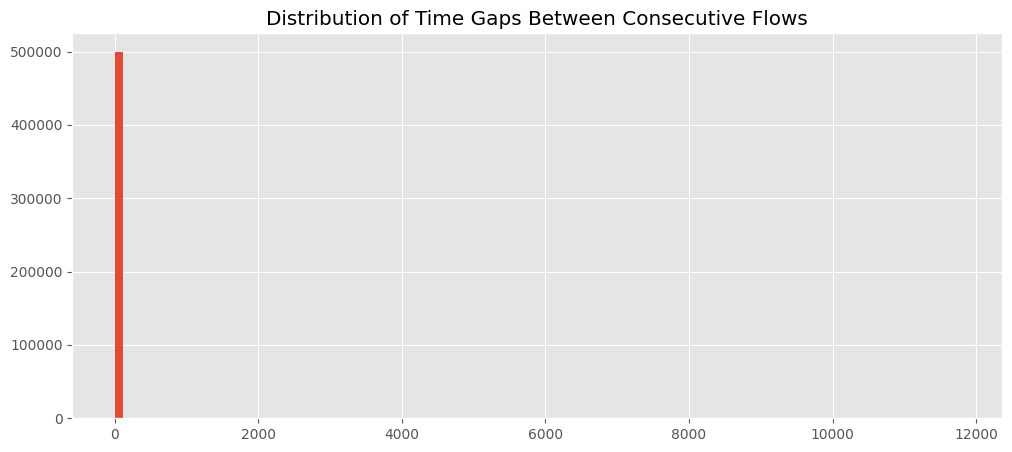

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

sample["TimeGap"].hist(
    bins=100
)

plt.title("Distribution of Time Gaps Between Consecutive Flows")

plt.show()

In [61]:
for i in range(32):

    df = pd.read_csv(
        chunk_files[i],
        usecols=["Label"]
    )

    print(f"Chunk {i+1}")
    print(df["Label"].value_counts())
    print("-"*50)

Chunk 1
Label
Benign    500000
Name: count, dtype: int64
--------------------------------------------------
Chunk 2
Label
Benign    500000
Name: count, dtype: int64
--------------------------------------------------
Chunk 3
Label
Benign    500000
Name: count, dtype: int64
--------------------------------------------------
Chunk 4
Label
Benign    500000
Name: count, dtype: int64
--------------------------------------------------
Chunk 5
Label
Benign    500000
Name: count, dtype: int64
--------------------------------------------------
Chunk 6
Label
Benign    500000
Name: count, dtype: int64
--------------------------------------------------
Chunk 7
Label
Benign    500000
Name: count, dtype: int64
--------------------------------------------------
Chunk 8
Label
Benign    500000
Name: count, dtype: int64
--------------------------------------------------
Chunk 9
Label
Benign    500000
Name: count, dtype: int64
--------------------------------------------------
Chunk 10
Label
Benign    500

Feature Statistics

In [62]:
sample = pd.read_csv(chunk_files[0])

numeric_cols = sample.select_dtypes(include="number").columns.tolist()

print(f"Numeric Features: {len(numeric_cols)}")

Numeric Features: 78


In [63]:
feature_stats = []

In [64]:
for feature in numeric_cols:

    print(f"Processing {feature}")

    values = []

    zero_count = 0
    total_count = 0

    for file in chunk_files:

        df = pd.read_csv(
            file,
            usecols=[feature]
        )

        col = df[feature]

        values.append(col)

        zero_count += (col == 0).sum()

        total_count += len(col)

    values = pd.concat(values, ignore_index=True)

    feature_stats.append({

        "Feature": feature,

        "Mean": values.mean(),

        "Std": values.std(),

        "Min": values.min(),

        "Max": values.max(),

        "Variance": values.var(),

        "Zero %": round(
            zero_count/total_count*100,
            2
        )

    })

Processing Dst Port
Processing Protocol
Processing Flow Duration
Processing Tot Fwd Pkts
Processing Tot Bwd Pkts
Processing TotLen Fwd Pkts
Processing TotLen Bwd Pkts
Processing Fwd Pkt Len Max
Processing Fwd Pkt Len Min
Processing Fwd Pkt Len Mean
Processing Fwd Pkt Len Std
Processing Bwd Pkt Len Max
Processing Bwd Pkt Len Min
Processing Bwd Pkt Len Mean
Processing Bwd Pkt Len Std
Processing Flow Byts/s
Processing Flow Pkts/s
Processing Flow IAT Mean
Processing Flow IAT Std
Processing Flow IAT Max
Processing Flow IAT Min
Processing Fwd IAT Tot
Processing Fwd IAT Mean
Processing Fwd IAT Std
Processing Fwd IAT Max
Processing Fwd IAT Min
Processing Bwd IAT Tot
Processing Bwd IAT Mean
Processing Bwd IAT Std
Processing Bwd IAT Max
Processing Bwd IAT Min
Processing Fwd PSH Flags
Processing Bwd PSH Flags
Processing Fwd URG Flags
Processing Bwd URG Flags
Processing Fwd Header Len
Processing Bwd Header Len
Processing Fwd Pkts/s
Processing Bwd Pkts/s
Processing Pkt Len Min
Processing Pkt Len Ma

In [65]:
stats_df = pd.DataFrame(feature_stats)

stats_df

,Feature,Mean,Std,Min,Max,Variance,Zero %
0,Dst Port,9.189542e+03,1.910771e+04,0.000000e+00,6.553500e+04,3.651046e+08,1.48
1,Protocol,8.805837e+00,4.949993e+00,0.000000e+00,1.700000e+01,2.450243e+01,1.48
2,Flow Duration,1.195292e+07,5.017800e+08,-9.190110e+11,1.200000e+08,2.517832e+17,0.60
3,Tot Fwd Pkts,2.412246e+01,1.545079e+03,1.000000e+00,3.096290e+05,2.387270e+06,0.00
4,Tot Bwd Pkts,6.350324e+00,1.638963e+02,0.000000e+00,1.231180e+05,2.686200e+04,25.10
...,...,...,...,...,...,...,...
73,Active Min,1.154745e+05,2.102946e+06,0.000000e+00,1.140000e+08,4.422384e+12,89.80
74,Idle Mean,5.084365e+06,2.674579e+08,0.000000e+00,3.955714e+11,7.153371e+16,85.30
75,Idle Std,2.934616e+05,1.718560e+08,0.000000e+00,2.622479e+11,2.953449e+16,91.95
76,Idle Max,5.506782e+06,6.352250e+08,0.000000e+00,9.797810e+11,4.035109e+17,85.30


In [66]:
stats_df.sort_values(
    "Zero %",
    ascending=False
)

,Feature,Mean,Std,Min,Max,Variance,Zero %
61,Bwd Blk Rate Avg,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,100.00
60,Bwd Pkts/b Avg,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,100.00
56,Fwd Byts/b Avg,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,100.00
57,Fwd Pkts/b Avg,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,100.00
32,Bwd PSH Flags,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,100.00
...,...,...,...,...,...,...,...
17,Flow IAT Mean,3.364050e+06,2.264516e+08,-8.282200e+11,120000000.0,5.128032e+16,0.60
66,Init Fwd Win Byts,8.864806e+03,1.638304e+04,-1.000000e+00,65535.0,2.684041e+08,0.49
3,Tot Fwd Pkts,2.412246e+01,1.545079e+03,1.000000e+00,309629.0,2.387270e+06,0.00
16,Flow Pkts/s,inf,NaN,-8.895325e-03,inf,NaN,0.00


In [67]:
stats_df.sort_values(
    "Variance",
    ascending=False
)

,Feature,Mean,Std,Min,Max,Variance,Zero %
25,Fwd IAT Min,2.413249e+06,7.594076e+08,-9.474050e+11,1.200000e+08,5.766999e+17,29.70
20,Flow IAT Min,2.324488e+06,7.594046e+08,-9.474050e+11,1.200000e+08,5.766953e+17,5.48
19,Flow IAT Max,6.696466e+06,6.699029e+08,-8.282200e+11,9.797810e+11,4.487699e+17,0.60
24,Fwd IAT Max,6.499440e+06,6.699009e+08,-8.282200e+11,9.797810e+11,4.487673e+17,28.86
76,Idle Max,5.506782e+06,6.352250e+08,0.000000e+00,9.797810e+11,4.035109e+17,85.30
...,...,...,...,...,...,...,...
56,Fwd Byts/b Avg,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,100.00
59,Bwd Byts/b Avg,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,100.00
58,Fwd Blk Rate Avg,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,100.00
15,Flow Byts/s,inf,NaN,0.000000e+00,inf,NaN,30.34


In [69]:
stats_df.to_csv(
    "/kaggle/working/feature_statistics.csv",
    index=False
)

In [70]:
problem_features = [
    "Flow Duration",
    "Flow IAT Mean",
    "Flow IAT Min",
    "Flow IAT Max",
    "Fwd IAT Min",
    "Fwd IAT Max"
]

for feature in problem_features:

    negative_count = 0

    for file in chunk_files:

        df = pd.read_csv(
            file,
            usecols=[feature]
        )

        negative_count += (df[feature] < 0).sum()

    print(f"{feature:20s} -> {negative_count:,}")

Flow Duration        -> 14
Flow IAT Mean        -> 14
Flow IAT Min         -> 15
Flow IAT Max         -> 3
Fwd IAT Min          -> 15
Fwd IAT Max          -> 3


In [71]:
constant_features = stats_df[
    stats_df["Variance"] == 0
]["Feature"].tolist()

print("Constant Features:", len(constant_features))
print(constant_features)

Constant Features: 8
['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg']


In [73]:
constant_features = [
    "Bwd PSH Flags",
    "Bwd URG Flags",
    "Fwd Byts/b Avg",
    "Fwd Pkts/b Avg",
    "Fwd Blk Rate Avg",
    "Bwd Byts/b Avg",
    "Bwd Pkts/b Avg",
    "Bwd Blk Rate Avg"
]

sample = pd.read_csv(chunk_files[0])

sample = sample.drop(columns=constant_features)

In [74]:
import pandas as pd
import numpy as np

sample_list = []

ROWS_PER_CHUNK = 10000

In [75]:
for file in chunk_files:

    df = pd.read_csv(file)

    # Remove constant features
    df = df.drop(columns=constant_features)

    # Replace infinities
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Fill justified NaNs
    df["Flow Byts/s"] = df["Flow Byts/s"].fillna(0)
    df["Flow Pkts/s"] = df["Flow Pkts/s"].fillna(0)

    # Random sample
    if len(df) > ROWS_PER_CHUNK:
        df = df.sample(
            ROWS_PER_CHUNK,
            random_state=42
        )

    sample_list.append(df)

In [77]:
corr_df = pd.concat(
    sample_list,
    ignore_index=True
)

print(corr_df.shape)

(320000, 72)


In [78]:
numeric = corr_df.select_dtypes(include=np.number)

corr_matrix = numeric.corr(method="pearson")

In [80]:
high_corr = []

cols = corr_matrix.columns

for i in range(len(cols)):
    for j in range(i+1, len(cols)):

        corr = corr_matrix.iloc[i, j]

        if abs(corr) >= 0.95:

            high_corr.append([
                cols[i],
                cols[j],
                corr
            ])

In [81]:
high_corr_df = pd.DataFrame(
    high_corr,
    columns=[
        "Feature 1",
        "Feature 2",
        "Correlation"
    ]
)

high_corr_df = high_corr_df.sort_values(
    "Correlation",
    ascending=False
)

high_corr_df

,Feature 1,Feature 2,Correlation
3,Tot Fwd Pkts,Subflow Fwd Pkts,1.000000
12,TotLen Fwd Pkts,Subflow Fwd Byts,1.000000
8,Tot Bwd Pkts,Subflow Bwd Pkts,1.000000
30,Fwd PSH Flags,SYN Flag Cnt,1.000000
21,Bwd Pkt Len Mean,Bwd Seg Size Avg,1.000000
18,Fwd Pkt Len Mean,Fwd Seg Size Avg,1.000000
16,TotLen Bwd Pkts,Subflow Bwd Byts,1.000000
31,Fwd URG Flags,CWE Flag Count,1.000000
39,RST Flag Cnt,ECE Flag Cnt,1.000000
7,Tot Bwd Pkts,Bwd Header Len,0.999795


In [83]:
high_corr_df.to_csv(
    "/kaggle/working/high_correlation_pairs.csv",
    index=False
)

feature_selection

In [84]:
import pandas as pd
import numpy as np
import os

# Constant features (Variance = 0)
constant_features = [
    "Bwd PSH Flags",
    "Bwd URG Flags",
    "Fwd Byts/b Avg",
    "Fwd Pkts/b Avg",
    "Fwd Blk Rate Avg",
    "Bwd Byts/b Avg",
    "Bwd Pkts/b Avg",
    "Bwd Blk Rate Avg"
]

# Exact duplicate features
duplicate_features = [
    "Subflow Fwd Pkts",
    "Subflow Bwd Pkts",
    "Subflow Fwd Byts",
    "Subflow Bwd Byts",
    "Fwd Seg Size Avg",
    "Bwd Seg Size Avg"
]

remove_features = constant_features + duplicate_features

print("Features to remove:", len(remove_features))
print(remove_features)

Features to remove: 14
['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg', 'Subflow Fwd Pkts', 'Subflow Bwd Pkts', 'Subflow Fwd Byts', 'Subflow Bwd Byts', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg']


In [85]:
from tqdm import tqdm

ROWS_PER_CHUNK = 10000

rf_samples = []

In [86]:
for file in tqdm(chunk_files):

    df = pd.read_csv(file, low_memory=False)

    # -------------------------------------------------
    # Remove constant & duplicate features
    # -------------------------------------------------
    df.drop(columns=remove_features, inplace=True)

    # -------------------------------------------------
    # Replace Infinity
    # -------------------------------------------------
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # -------------------------------------------------
    # Fill justified NaNs
    # -------------------------------------------------
    df["Flow Byts/s"] = df["Flow Byts/s"].fillna(0)
    df["Flow Pkts/s"] = df["Flow Pkts/s"].fillna(0)

    # -------------------------------------------------
    # Remove corrupted rows (negative time values)
    # -------------------------------------------------
    df = df[
        (df["Flow Duration"] >= 0) &
        (df["Flow IAT Mean"] >= 0) &
        (df["Flow IAT Min"] >= 0) &
        (df["Flow IAT Max"] >= 0) &
        (df["Fwd IAT Min"] >= 0) &
        (df["Fwd IAT Max"] >= 0)
    ]

    # -------------------------------------------------
    # Sample
    # -------------------------------------------------
    if len(df) > ROWS_PER_CHUNK:
        df = df.sample(
            n=ROWS_PER_CHUNK,
            random_state=42
        )

    rf_samples.append(df)

100%|██████████| 32/32 [04:55<00:00,  9.22s/it]


In [87]:
rf_df = pd.concat(
    rf_samples,
    ignore_index=True
)

print(rf_df.shape)

(320000, 66)


In [88]:
print(rf_df["Label"].value_counts())

Label
Benign                      269374
DDOS attack-HOIC             13693
DDoS attacks-LOIC-HTTP       11496
DoS attacks-Hulk              9203
Infilteration                 4852
FTP-BruteForce                3850
SSH-Bruteforce                3666
DoS attacks-SlowHTTPTest      2787
DoS attacks-GoldenEye          804
DoS attacks-Slowloris          229
DDOS attack-LOIC-UDP            28
Brute Force -Web                11
Brute Force -XSS                 4
SQL Injection                    3
Name: count, dtype: int64


In [89]:
from sklearn.preprocessing import LabelEncoder

# Features
X = rf_df.drop(columns=["Label", "Timestamp"])

# Labels
y = rf_df["Label"]

print("Feature Shape :", X.shape)
print("Label Shape   :", y.shape)

Feature Shape : (320000, 64)
Label Shape   : (320000,)


In [90]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Number of Classes:", len(label_encoder.classes_))
print(label_encoder.classes_)

Number of Classes: 14
['Benign' 'Brute Force -Web' 'Brute Force -XSS' 'DDOS attack-HOIC'
 'DDOS attack-LOIC-UDP' 'DDoS attacks-LOIC-HTTP' 'DoS attacks-GoldenEye'
 'DoS attacks-Hulk' 'DoS attacks-SlowHTTPTest' 'DoS attacks-Slowloris'
 'FTP-BruteForce' 'Infilteration' 'SQL Injection' 'SSH-Bruteforce']


In [91]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

rf.fit(X, y_encoded)

RandomForestClassifier(class_weight='balanced_subsample', n_estimators=200,
                       n_jobs=-1, random_state=42)

In [93]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.reset_index(drop=True, inplace=True)

importance_df.head(20)

,Feature,Importance
0,Init Fwd Win Byts,0.077201
1,Fwd Seg Size Min,0.074728
2,Fwd Header Len,0.052570
3,Dst Port,0.052468
4,Flow Duration,0.039978
5,Flow IAT Max,0.037519
6,Fwd Pkts/s,0.035067
7,Flow Pkts/s,0.032898
8,Flow IAT Mean,0.031376
9,Init Bwd Win Byts,0.029508


In [95]:
importance_df.to_csv(
    "/kaggle/working/feature_importance.csv",
    index=False
)

In [96]:
importance_df.tail(20)

,Feature,Importance
44,ECE Flag Cnt,0.004050
45,Pkt Len Min,0.004046
46,URG Flag Cnt,0.003550
47,Idle Max,0.003016
48,Down/Up Ratio,0.002955
49,Fwd Pkt Len Min,0.002382
50,Idle Mean,0.001720
51,Idle Min,0.001666
52,Idle Std,0.001430
53,Active Mean,0.001191


In [97]:
importance_df["Cumulative"] = importance_df["Importance"].cumsum()

importance_df.head(40)

,Feature,Importance,Cumulative
0,Init Fwd Win Byts,0.077201,0.077201
1,Fwd Seg Size Min,0.074728,0.151930
2,Fwd Header Len,0.052570,0.204499
3,Dst Port,0.052468,0.256968
4,Flow Duration,0.039978,0.296945
5,Flow IAT Max,0.037519,0.334465
6,Fwd Pkts/s,0.035067,0.369532
7,Flow Pkts/s,0.032898,0.402430
8,Flow IAT Mean,0.031376,0.433806
9,Init Bwd Win Byts,0.029508,0.463314


In [99]:
# Already removed
excluded_features = set(
    constant_features +
    duplicate_features
)

In [100]:
correlation_remove = [
    "Pkt Len Mean",      # Keep Pkt Size Avg
]

In [101]:
TOP_K = 35

selected_features = []

for feature in importance_df["Feature"]:

    if feature not in excluded_features and feature not in correlation_remove:
        selected_features.append(feature)

    if len(selected_features) == TOP_K:
        break

In [102]:
print(f"Selected Features: {len(selected_features)}")

for i, feature in enumerate(selected_features, start=1):
    print(f"{i:2d}. {feature}")

Selected Features: 35
 1. Init Fwd Win Byts
 2. Fwd Seg Size Min
 3. Fwd Header Len
 4. Dst Port
 5. Flow Duration
 6. Flow IAT Max
 7. Fwd Pkts/s
 8. Flow Pkts/s
 9. Flow IAT Mean
10. Init Bwd Win Byts
11. Fwd IAT Tot
12. Bwd Pkts/s
13. Tot Fwd Pkts
14. Flow IAT Min
15. TotLen Fwd Pkts
16. Fwd IAT Max
17. Fwd IAT Mean
18. Fwd Act Data Pkts
19. Fwd IAT Min
20. Flow IAT Std
21. Fwd Pkt Len Std
22. Bwd IAT Min
23. Bwd Header Len
24. Bwd IAT Mean
25. Pkt Len Max
26. Bwd Pkt Len Max
27. Fwd Pkt Len Max
28. Bwd Pkt Len Std
29. Fwd IAT Std
30. Bwd IAT Max
31. Pkt Len Std
32. Pkt Len Var
33. Fwd Pkt Len Mean
34. Tot Bwd Pkts
35. Bwd Pkt Len Mean


In [103]:
pd.DataFrame({
    "Selected Features": selected_features
}).to_csv(
    "/kaggle/working/final_selected_features.csv",
    index=False
)

Temporal Feature Engineering

In [104]:
INPUT_DIR = "/kaggle/working/CIC_IDS2018_Cleaned"

OUTPUT_DIR = "/kaggle/working/CIC_IDS2018_HTRE"

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [105]:
chunk_files = sorted([
    os.path.join(INPUT_DIR, f)
    for f in os.listdir(INPUT_DIR)
    if f.endswith(".csv")
])

print(len(chunk_files))

32


In [113]:
for file in tqdm(chunk_files):

    df = pd.read_csv(file)

    # Timestamp
    df["Timestamp"] = pd.to_datetime(
        df["Timestamp"],
        format="%Y-%m-%d %H:%M:%S"
    )

    df["OriginalOrder"] = np.arange(len(df))
    
    # Chronological ordering
    df = (
        df.sort_values(
            by="Timestamp",
            kind="mergesort"
        )
        .reset_index(drop=True)
    )

    ##################################################
    # HTRE Feature 1
    ##################################################

    df["TimeGap"] = (
        df["Timestamp"]
        .diff()
        .dt.total_seconds()
    )

    # first flow
    df["TimeGap"] = df["TimeGap"].fillna(0)

    ##################################################
    # HTRE Feature 2
    ##################################################

    start_time = df["Timestamp"].iloc[0]
    end_time = df["Timestamp"].iloc[-1]

    total_seconds = (
        end_time -
        start_time
    ).total_seconds()

    if total_seconds == 0:

        df["RelativeTime"] = 0

    else:

        df["RelativeTime"] = (
            (
                df["Timestamp"] -
                start_time
            )
            .dt.total_seconds()
            /
            total_seconds
        )

    ##################################################
    # Save
    ##################################################

    save_name = os.path.basename(file)

    df.to_csv(
        os.path.join(
            OUTPUT_DIR,
            save_name
        ),
        index=False
    )

100%|██████████| 32/32 [17:36<00:00, 33.01s/it]


In [114]:
test = pd.read_csv(
    os.path.join(
        OUTPUT_DIR,
        os.listdir(OUTPUT_DIR)[0]
    )
)

print(test[[
    "Timestamp",
    "TimeGap",
    "RelativeTime"
]].head(15))

              Timestamp  TimeGap  RelativeTime
0   2018-02-20 01:00:00      0.0      0.000000
1   2018-02-20 01:00:00      0.0      0.000000
2   2018-02-20 01:00:00      0.0      0.000000
3   2018-02-20 01:00:00      0.0      0.000000
4   2018-02-20 01:00:01      1.0      0.000023
5   2018-02-20 01:00:01      0.0      0.000023
6   2018-02-20 01:00:01      0.0      0.000023
7   2018-02-20 01:00:02      1.0      0.000046
8   2018-02-20 01:00:02      0.0      0.000046
9   2018-02-20 01:00:02      0.0      0.000046
10  2018-02-20 01:00:03      1.0      0.000069
11  2018-02-20 01:00:04      1.0      0.000093
12  2018-02-20 01:00:04      0.0      0.000093
13  2018-02-20 01:00:04      0.0      0.000093
14  2018-02-20 01:00:05      1.0      0.000116


In [115]:
print(test["TimeGap"].describe())

print(test["RelativeTime"].describe())

count    500000.000000
mean          0.086398
std          12.254246
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        8662.000000
Name: TimeGap, dtype: float64
count    500000.000000
mean          0.479380
std           0.318576
min           0.000000
25%           0.182111
50%           0.361768
75%           0.778930
max           1.000000
Name: RelativeTime, dtype: float64


In [112]:
import shutil
import os

HTRE_DIR = "/kaggle/working/CIC_IDS2018_HTRE"

if os.path.exists(HTRE_DIR):
    shutil.rmtree(HTRE_DIR)

os.makedirs(HTRE_DIR, exist_ok=True)

print("Fresh HTRE directory created.")

Fresh HTRE directory created.


In [116]:
print(test["TimeGap"].value_counts().head(20))

TimeGap
0.0     467464
1.0      31865
2.0        439
3.0         52
5.0         34
6.0         28
4.0         27
7.0         19
8.0         13
9.0         10
11.0         6
14.0         5
10.0         4
23.0         4
12.0         3
16.0         3
29.0         3
21.0         3
17.0         3
28.0         2
Name: count, dtype: int64


In [118]:
df.rename(columns={
    "TimeGap": "TRE_TimeGap",
    "RelativeTime": "TRE_RelativeTime"
}, inplace=True)

htre2

In [133]:
##################################################
# HTRE Level 2 : Temporal Change Encoding
##################################################

# Log-transform current and previous values
current_duration = np.log1p(df["Flow Duration"])
previous_duration = np.log1p(df["Flow Duration"].shift(1))

current_pkts = np.log1p(df["Flow Pkts/s"])
previous_pkts = np.log1p(df["Flow Pkts/s"].shift(1))

current_byts = np.log1p(df["Flow Byts/s"])
previous_byts = np.log1p(df["Flow Byts/s"].shift(1))

In [134]:
##################################################
# Log Temporal Change Features
##################################################

df["TRE_LogFlowDurationChange"] = (
    current_duration - previous_duration
).fillna(0)

df["TRE_LogFlowPktsChange"] = (
    current_pkts - previous_pkts
).fillna(0)

df["TRE_LogFlowBytsChange"] = (
    current_byts - previous_byts
).fillna(0)

In [135]:
features = [
    "TRE_LogFlowDurationChange",
    "TRE_LogFlowPktsChange",
    "TRE_LogFlowBytsChange"
]

for feature in features:

    print("=" * 60)
    print(feature)
    print("=" * 60)

    print(df[feature].describe())

    print("\nNaN :", df[feature].isna().sum())
    print("Inf :", np.isinf(df[feature]).sum())

    print()

TRE_LogFlowDurationChange
count    500000.000000
mean         -0.000012
std           5.560181
min         -18.602941
25%          -2.414289
50%           0.001520
75%           2.296769
max          18.602400
Name: TRE_LogFlowDurationChange, dtype: float64

NaN : 0
Inf : 0

TRE_LogFlowPktsChange
count    500000.000000
mean          0.006667
std           4.289104
min         -14.887838
25%          -1.520410
50%           0.000000
75%           1.620877
max          14.887839
Name: TRE_LogFlowPktsChange, dtype: float64

NaN : 0
Inf : 0

TRE_LogFlowBytsChange
count    500000.000000
mean          0.015510
std           6.003086
min         -19.421313
25%          -2.789502
50%           0.000000
75%           3.423269
max          19.693246
Name: TRE_LogFlowBytsChange, dtype: float64

NaN : 0
Inf : 0



In [136]:
df[
    [
        "Flow Duration",
        "Flow Pkts/s",
        "Flow Byts/s",
        "TRE_LogFlowDurationChange",
        "TRE_LogFlowPktsChange",
        "TRE_LogFlowBytsChange"
    ]
].head(15)

,Flow Duration,Flow Pkts/s,Flow Byts/s,TRE_LogFlowDurationChange,TRE_LogFlowPktsChange,TRE_LogFlowBytsChange
0,1411981,8.498698,669.980687,0.000000,0.000000,0.000000
1,35,57142.857143,0.000000,-10.576986,8.702172,-6.508740
2,60339600,0.331457,123.368402,14.331980,-10.667053,4.823248
3,3211,622.858922,66023.045780,-9.840850,6.149650,6.274526
4,54033154,0.037014,0.000000,9.730459,-6.399579,-11.097774
5,2227487,6.734046,1225.147442,-3.188723,2.009286,7.111632
6,318,9433.962264,242138.364780,-8.851194,7.106545,5.285636
7,405,7407.407407,190123.456790,0.241162,-0.241807,-0.241835
8,45,44444.444444,0.000000,-2.177712,1.791647,-12.155434
9,20,100000.000000,0.000000,-0.784119,0.810918,0.000000


In [137]:
#htre validation

In [138]:
sample = df.sample(
    n=300000,
    random_state=42
)

In [139]:
htre_features = [
    "TRE_TimeGap",
    "TRE_RelativeTime",
    "TRE_LogFlowDurationChange",
    "TRE_LogFlowPktsChange",
    "TRE_LogFlowBytsChange"
]

In [140]:
selected_features = [
    "Init Fwd Win Byts",
    "Fwd Seg Size Min",
    "Fwd Header Len",
    "Dst Port",
    "Flow Duration",
    "Flow IAT Max",
    "Fwd Pkts/s",
    "Flow Pkts/s",
    "Flow IAT Mean",
    "Init Bwd Win Byts",
    "Fwd IAT Tot",
    "Bwd Pkts/s",
    "Tot Fwd Pkts",
    "Flow IAT Min",
    "TotLen Fwd Pkts",
    "Fwd IAT Max",
    "Fwd IAT Mean",
    "Fwd Act Data Pkts",
    "Fwd IAT Min",
    "Flow IAT Std",
    "Fwd Pkt Len Std",
    "Bwd IAT Min",
    "Bwd Header Len",
    "Bwd IAT Mean",
    "Pkt Len Max",
    "Bwd Pkt Len Max",
    "Fwd Pkt Len Max",
    "Bwd Pkt Len Std",
    "Fwd IAT Std",
    "Bwd IAT Max",
    "Pkt Len Std",
    "Pkt Len Var",
    "Fwd Pkt Len Mean",
    "Tot Bwd Pkts",
    "Bwd Pkt Len Mean"
]

In [141]:
corr = sample[
    selected_features + htre_features
].corr(method="pearson")

In [142]:
for feature in htre_features:

    print("=" * 70)
    print(feature)
    print("=" * 70)

    corr_values = (
        corr.loc[feature, selected_features]
        .abs()
        .sort_values(ascending=False)
        .head(10)
    )

    print(corr_values)
    print()

TRE_TimeGap
Fwd Seg Size Min     0.125349
Init Bwd Win Byts    0.113412
Fwd Pkt Len Std      0.085431
Flow IAT Min         0.085142
Fwd IAT Min          0.084659
Flow IAT Mean        0.084252
Fwd IAT Mean         0.079068
Fwd Pkt Len Max      0.070036
Init Fwd Win Byts    0.067530
Fwd Pkt Len Mean     0.048926
Name: TRE_TimeGap, dtype: float64

TRE_RelativeTime
Init Bwd Win Byts    0.042314
Init Fwd Win Byts    0.037005
Fwd Seg Size Min     0.025662
Fwd Pkt Len Std      0.023948
Fwd Act Data Pkts    0.021045
Fwd Pkt Len Max      0.020911
Flow IAT Min         0.018682
Fwd IAT Std          0.018339
Fwd IAT Min          0.018178
Bwd Pkt Len Mean     0.018126
Name: TRE_RelativeTime, dtype: float64

TRE_LogFlowDurationChange
Flow IAT Max       0.282162
Fwd IAT Mean       0.278117
Dst Port           0.277514
Fwd IAT Max        0.269821
Fwd Pkt Len Max    0.269655
Pkt Len Max        0.268990
Fwd Pkt Len Std    0.268817
Flow IAT Mean      0.268393
Bwd Pkt Len Max    0.265519
Bwd Pkt Len Std   

In [144]:
#rf validation

In [151]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

In [152]:
baseline_features = [
    "Init Fwd Win Byts",
    "Fwd Seg Size Min",
    "Fwd Header Len",
    "Dst Port",
    "Flow Duration",
    "Flow IAT Max",
    "Fwd Pkts/s",
    "Flow Pkts/s",
    "Flow IAT Mean",
    "Init Bwd Win Byts",
    "Fwd IAT Tot",
    "Bwd Pkts/s",
    "Tot Fwd Pkts",
    "Flow IAT Min",
    "TotLen Fwd Pkts",
    "Fwd IAT Max",
    "Fwd IAT Mean",
    "Fwd Act Data Pkts",
    "Fwd IAT Min",
    "Flow IAT Std",
    "Fwd Pkt Len Std",
    "Bwd IAT Min",
    "Bwd Header Len",
    "Bwd IAT Mean",
    "Pkt Len Max",
    "Bwd Pkt Len Max",
    "Fwd Pkt Len Max",
    "Bwd Pkt Len Std",
    "Fwd IAT Std",
    "Bwd IAT Max",
    "Pkt Len Std",
    "Pkt Len Var",
    "Fwd Pkt Len Mean",
    "Tot Bwd Pkts",
    "Bwd Pkt Len Mean"
]

htre_features = [
    "TRE_TimeGap",
    "TRE_RelativeTime",
    "TRE_LogFlowDurationChange",
    "TRE_LogFlowPktsChange",
    "TRE_LogFlowBytsChange"
]

all_features = baseline_features + htre_features

In [162]:
validation_parts = []

SAMPLE_SIZE = 10000

for file in chunk_files:

    chunk = pd.read_csv(file)

    n = min(SAMPLE_SIZE, len(chunk))

    validation_parts.append(
        chunk.sample(
            n=n,
            random_state=42
        )
    )

validation_df = pd.concat(
    validation_parts,
    ignore_index=True
)

print(validation_df.shape)

(320000, 80)


In [163]:
validation_df["Label"].value_counts()

Label
Benign                      269296
DDOS attack-HOIC             13693
DDoS attacks-LOIC-HTTP       11497
DoS attacks-Hulk              9203
Infilteration                 4852
FTP-BruteForce                3846
SSH-Bruteforce                3747
DoS attacks-SlowHTTPTest      2787
DoS attacks-GoldenEye          804
DoS attacks-Slowloris          229
DDOS attack-LOIC-UDP            28
Brute Force -Web                11
Brute Force -XSS                 4
SQL Injection                    3
Name: count, dtype: int64

In [175]:
import numpy as np

rate_columns = [
    "Flow Pkts/s",
    "Flow Byts/s"
]

for col in rate_columns:

    # Replace infinities with NaN
    validation_df[col] = validation_df[col].replace(
        [np.inf, -np.inf],
        np.nan
    )

    # Median imputation
    validation_df[col] = validation_df[col].fillna(
        validation_df[col].median()
    )

In [176]:
import numpy as np
import pandas as pd

def apply_htre_level1(df):

    df = df.copy()

    # Timestamp
    df["Timestamp"] = pd.to_datetime(
        df["Timestamp"],
        format="%Y-%m-%d %H:%M:%S"
    )

    # Preserve original order
    df["OriginalOrder"] = np.arange(len(df))

    # Chronological Alignment
    df = (
        df.sort_values(
            by="Timestamp",
            kind="stable"
        )
        .reset_index(drop=True)
    )

    ##################################################
    # TRE_TimeGap
    ##################################################

    df["TRE_TimeGap"] = (
        df["Timestamp"]
        .diff()
        .dt.total_seconds()
        .fillna(0)
    )

    ##################################################
    # TRE_RelativeTime
    ##################################################

    start = df["Timestamp"].iloc[0]
    end = df["Timestamp"].iloc[-1]

    total = (end - start).total_seconds()

    if total == 0:
        df["TRE_RelativeTime"] = 0
    else:
        df["TRE_RelativeTime"] = (
            (df["Timestamp"] - start)
            .dt.total_seconds()
            / total
        )

    return df

In [178]:
def apply_htre_level2(df):

    df = df.copy()

    ##################################################
    # Log Flow Duration Change
    ##################################################

    current = np.log1p(df["Flow Duration"])
    previous = np.log1p(df["Flow Duration"].shift(1))

    df["TRE_LogFlowDurationChange"] = (
        current - previous
    ).fillna(0)

    ##################################################
    # Log Flow Pkts/s Change
    ##################################################

    current = np.log1p(df["Flow Pkts/s"])
    previous = np.log1p(df["Flow Pkts/s"].shift(1))

    df["TRE_LogFlowPktsChange"] = (
        current - previous
    ).fillna(0)

    ##################################################
    # Log Flow Byts/s Change
    ##################################################

    current = np.log1p(df["Flow Byts/s"])
    previous = np.log1p(df["Flow Byts/s"].shift(1))

    df["TRE_LogFlowBytsChange"] = (
        current - previous
    ).fillna(0)

    return df

In [179]:
validation_df = apply_htre_level1(validation_df)

validation_df = apply_htre_level2(validation_df)

In [180]:
from sklearn.preprocessing import LabelEncoder

X = validation_df[all_features]

y = validation_df["Label"]

le = LabelEncoder()
y = le.fit_transform(y)

In [181]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [182]:
importance = pd.DataFrame({

    "Feature": all_features,

    "Importance": rf.feature_importances_

})

importance = importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

importance.head(40)

,Feature,Importance
0,TRE_RelativeTime,0.101031
1,Init Fwd Win Byts,0.099582
2,Fwd Seg Size Min,0.082954
3,Dst Port,0.061766
4,Flow Duration,0.036410
5,Fwd Pkt Len Max,0.036172
6,Fwd Pkt Len Mean,0.034736
7,Fwd IAT Tot,0.033009
8,Flow IAT Max,0.031596
9,TotLen Fwd Pkts,0.031133


In [183]:
importance[
    importance["Feature"].isin(htre_features)
]

,Feature,Importance
0,TRE_RelativeTime,0.101031
26,TRE_LogFlowDurationChange,0.011020
27,TRE_LogFlowPktsChange,0.010300
33,TRE_LogFlowBytsChange,0.006244
34,TRE_TimeGap,0.005556


In [ ]:
#ablation

In [184]:
all_features_no_rt = [
    f for f in all_features
    if f != "TRE_RelativeTime"
]

print(len(all_features_no_rt))

39


In [186]:
X = validation_df[all_features_no_rt]

y = validation_df["Label"]

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

In [187]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [188]:
importance = pd.DataFrame({

    "Feature": all_features_no_rt,

    "Importance": rf.feature_importances_

})

importance = importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

importance

,Feature,Importance
0,Init Fwd Win Byts,0.106972
1,Dst Port,0.087541
2,Fwd Seg Size Min,0.084643
3,Flow IAT Max,0.043639
4,Fwd Header Len,0.042034
5,Flow Duration,0.039655
6,Bwd Pkts/s,0.036579
7,Fwd Pkt Len Max,0.036117
8,TotLen Fwd Pkts,0.035502
9,Flow IAT Min,0.032098


In [189]:
importance[
    importance["Feature"].str.startswith("TRE")
]

,Feature,Importance
18,TRE_LogFlowDurationChange,0.019586
19,TRE_LogFlowPktsChange,0.018742
29,TRE_LogFlowBytsChange,0.010906
34,TRE_TimeGap,0.006480


In [190]:
validation_df.groupby("Label")["TRE_RelativeTime"].mean().sort_values()

Label
SSH-Bruteforce              0.004497
FTP-BruteForce              0.026179
DoS attacks-GoldenEye       0.082683
DoS attacks-Slowloris       0.086731
DoS attacks-Hulk            0.123188
DoS attacks-SlowHTTPTest    0.145270
DDoS attacks-LOIC-HTTP      0.388231
Benign                      0.415790
DDOS attack-HOIC            0.427622
DDOS attack-LOIC-UDP        0.448061
Brute Force -XSS            0.517214
SQL Injection               0.531708
Brute Force -Web            0.537065
Infilteration               0.887383
Name: TRE_RelativeTime, dtype: float64

HTRE3

In [192]:
WINDOW = 10

In [200]:
def apply_htre_level3(df, window=10):

    df = df.copy()

    ##################################################
    # Previous-flow rolling statistics
    ##################################################

    prev_duration = df["Flow Duration"].shift(1)
    prev_pkts = df["Flow Pkts/s"].shift(1)

    ##################################################
    # Flow Duration Context
    ##################################################

    df["TRE_RollMeanFlowDuration"] = (
        prev_duration
        .rolling(window=window, min_periods=1)
        .mean()
    )

    df["TRE_RollStdFlowDuration"] = (
        prev_duration
        .rolling(window=window, min_periods=1)
        .std()
        .fillna(0)
    )

    # epsilon = 1e-6

    # df["TRE_ContextDeviationFlowDuration"] = (
    #     (df["Flow Duration"] - df["TRE_RollMeanFlowDuration"])
    #     /
    #     (df["TRE_RollStdFlowDuration"] + epsilon)
    # )

    ##################################################
    # Flow Packets/s Context
    ##################################################

    df["TRE_RollMeanFlowPkts"] = (
        prev_pkts
        .rolling(window=window, min_periods=1)
        .mean()
    )

    df["TRE_RollStdFlowPkts"] = (
        prev_pkts
        .rolling(window=window, min_periods=1)
        .std()
        .fillna(0)
    )

    # df["TRE_ContextDeviationFlowPkts"] = (
    #     (df["Flow Pkts/s"] - df["TRE_RollMeanFlowPkts"])
    #     /
    #     (df["TRE_RollStdFlowPkts"] + epsilon)
    # )

    return df

In [201]:
validation_df = apply_htre_level3(validation_df, window=10)


In [202]:
level3_features = [
    "TRE_RollMeanFlowDuration",
    "TRE_RollStdFlowDuration",
    # "TRE_ContextDeviationFlowDuration",
    "TRE_RollMeanFlowPkts",
    "TRE_RollStdFlowPkts"
    # "TRE_ContextDeviationFlowPkts"
]

validation_df[level3_features] = (
    validation_df[level3_features]
    .fillna(0)
)

for feature in level3_features:

    print("=" * 60)
    print(feature)
    print("=" * 60)

    print(validation_df[feature].describe())

    print("\nNaN :", validation_df[feature].isna().sum())
    print("Inf :", np.isinf(validation_df[feature]).sum())

    print()

TRE_RollMeanFlowDuration
count    3.200000e+05
mean     1.241066e+07
std      1.145683e+07
min      0.000000e+00
25%      1.756991e+06
50%      1.158449e+07
75%      1.913191e+07
max      1.176823e+08
Name: TRE_RollMeanFlowDuration, dtype: float64

NaN : 0
Inf : 0

TRE_RollStdFlowDuration
count    3.200000e+05
mean     2.424556e+07
std      1.856887e+07
min      0.000000e+00
25%      2.250227e+06
50%      2.746371e+07
75%      3.846654e+07
max      6.305384e+07
Name: TRE_RollStdFlowDuration, dtype: float64

NaN : 0
Inf : 0

TRE_RollMeanFlowPkts
count    3.200000e+05
mean     5.371484e+04
std      1.437739e+05
min      0.000000e+00
25%      1.911505e+03
50%      6.466322e+03
75%      1.750505e+04
max      1.600002e+06
Name: TRE_RollMeanFlowPkts, dtype: float64

NaN : 0
Inf : 0

TRE_RollStdFlowPkts
count    3.200000e+05
mean     9.887767e+04
std      2.183607e+05
min      0.000000e+00
25%      2.812027e+03
50%      1.347469e+04
75%      3.512877e+04
max      1.349726e+06
Name: TRE_RollSt

In [ ]:
#VALIDATION(HTRE3)

In [203]:
htre_core = [
    "TRE_TimeGap",
    "TRE_LogFlowDurationChange",
    "TRE_LogFlowPktsChange",
    "TRE_LogFlowBytsChange",
    "TRE_RollMeanFlowDuration",
    "TRE_RollStdFlowDuration",
    "TRE_RollMeanFlowPkts",
    "TRE_RollStdFlowPkts"
]

In [204]:
corr = validation_df[
    baseline_features + htre_core
].corr(method="pearson")

In [205]:
for feature in htre_core:

    print("=" * 70)
    print(feature)
    print("=" * 70)

    corr_values = (
        corr.loc[feature, baseline_features]
        .abs()
        .sort_values(ascending=False)
        .head(10)
    )

    print(corr_values)
    print()

TRE_TimeGap
Pkt Len Var         0.003121
Bwd Pkt Len Std     0.002939
Pkt Len Std         0.002513
Bwd Pkt Len Max     0.002443
Pkt Len Max         0.002242
Bwd Pkt Len Mean    0.001895
Bwd IAT Max         0.001596
Flow IAT Std        0.001415
Fwd Seg Size Min    0.001393
Dst Port            0.001338
Name: TRE_TimeGap, dtype: float64

TRE_LogFlowDurationChange
Flow Duration      0.431464
Fwd IAT Tot        0.424591
Pkt Len Max        0.402338
Bwd Pkt Len Max    0.394993
Bwd Pkt Len Std    0.376580
Pkt Len Std        0.374461
Flow IAT Max       0.365197
Fwd IAT Max        0.357555
Fwd Pkt Len Max    0.336501
Pkt Len Var        0.326368
Name: TRE_LogFlowDurationChange, dtype: float64

TRE_LogFlowPktsChange
Flow Duration      0.362905
Fwd IAT Tot        0.356127
Pkt Len Max        0.354954
Bwd Pkt Len Max    0.351369
Bwd Pkt Len Std    0.331733
Pkt Len Std        0.325983
Flow IAT Max       0.318194
Fwd IAT Max        0.310354
Fwd Pkt Len Max    0.297230
Pkt Len Var        0.276788
Name: 

In [ ]:
#RF

In [206]:
all_features_final = baseline_features + htre_core

In [207]:
from sklearn.preprocessing import LabelEncoder

X = validation_df[all_features_final]

y = validation_df["Label"]

le = LabelEncoder()

y = le.fit_transform(y)

In [208]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [209]:
importance = pd.DataFrame({

    "Feature": all_features_final,

    "Importance": rf.feature_importances_

})

importance = (
    importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

importance

,Feature,Importance
0,TRE_RollStdFlowDuration,0.082506
1,Fwd Seg Size Min,0.076149
2,Init Fwd Win Byts,0.069972
3,Dst Port,0.066914
4,TRE_RollMeanFlowDuration,0.058366
5,Fwd Pkt Len Max,0.039147
6,Fwd Header Len,0.035081
7,TotLen Fwd Pkts,0.033595
8,TRE_RollMeanFlowPkts,0.029463
9,TRE_RollStdFlowPkts,0.028970


In [210]:
htre_results = importance[
    importance["Feature"].isin(htre_core)
].copy()

htre_results["Rank"] = htre_results.index + 1

htre_results.sort_values("Rank")

,Feature,Importance,Rank
0,TRE_RollStdFlowDuration,0.082506,1
4,TRE_RollMeanFlowDuration,0.058366,5
8,TRE_RollMeanFlowPkts,0.029463,9
9,TRE_RollStdFlowPkts,0.028970,10
33,TRE_LogFlowDurationChange,0.007360,34
34,TRE_LogFlowPktsChange,0.006775,35
38,TRE_LogFlowBytsChange,0.005379,39
40,TRE_TimeGap,0.003908,41


DATA FOR TRAINING

In [219]:
import os

INPUT_DIR = "/kaggle/working/CIC_IDS2018_Cleaned"
OUTPUT_DIR = "/kaggle/working/CIC_IDS2018_HTRE_Final"

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [220]:
def apply_htre(df):

    df = df.copy()

    ##########################################################
    # Safety Cleaning
    ##########################################################

    numeric_cols = [
        "Flow Duration",
        "Flow Pkts/s",
        "Flow Byts/s"
    ]

    for col in numeric_cols:

        # Replace infinities
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)

        # Remove impossible negative values
        df.loc[df[col] < 0, col] = np.nan

        # Fill missing values with median
        df[col] = df[col].fillna(df[col].median())

    ##########################################################
    # HTRE Level 1
    ##########################################################

    df = apply_htre_level1(df)

    ##########################################################
    # HTRE Level 2
    ##########################################################

    df = apply_htre_level2(df)

    ##########################################################
    # HTRE Level 3
    ##########################################################

    df = apply_htre_level3(
        df,
        window=10
    )

    ##########################################################
    # Final Safety Check (HTRE features)
    ##########################################################

    htre_cols = [c for c in df.columns if c.startswith("TRE_")]

    for col in htre_cols:

        df[col] = df[col].replace([np.inf, -np.inf], np.nan)

        if df[col].isna().any():
            df[col] = df[col].fillna(0)

    return df

In [221]:
from tqdm import tqdm
import pandas as pd
import os

chunk_files = sorted([
    f for f in os.listdir(INPUT_DIR)
    if f.endswith(".csv")
])

print("Total chunks:", len(chunk_files))

Total chunks: 32


In [224]:
for file in tqdm(chunk_files):

    save_path = os.path.join(OUTPUT_DIR, file)

    # Skip already processed chunks
    if os.path.exists(save_path):
        continue

    print(f"Processing {file}")

    df = pd.read_csv(os.path.join(INPUT_DIR, file))

    df = apply_htre(df)

    df.to_csv(save_path, index=False)

  0%|          | 0/32 [00:00<?, ?it/s]

Processing clean_chunk_10.csv


  6%|▋         | 2/32 [00:54<13:34, 27.15s/it]

Processing clean_chunk_11.csv


  9%|▉         | 3/32 [01:41<17:05, 35.36s/it]

...

 94%|█████████▍| 30/32 [20:12<01:19, 39.66s/it]

Processing clean_chunk_8.csv


 97%|█████████▋| 31/32 [20:58<00:41, 41.77s/it]

Processing clean_chunk_9.csv


100%|██████████| 32/32 [21:55<00:00, 41.12s/it]


In [225]:
print(len(os.listdir(OUTPUT_DIR)))

32


In [226]:
sample = pd.read_csv(
    os.path.join(
        OUTPUT_DIR,
        chunk_files[0]
    )
)

print(sample.shape)

print(sample.columns[-10:])

(498028, 90)
Index(['OriginalOrder', 'TRE_TimeGap', 'TRE_RelativeTime',
       'TRE_LogFlowDurationChange', 'TRE_LogFlowPktsChange',
       'TRE_LogFlowBytsChange', 'TRE_RollMeanFlowDuration',
       'TRE_RollStdFlowDuration', 'TRE_RollMeanFlowPkts',
       'TRE_RollStdFlowPkts'],
      dtype='object')


In [228]:
from tqdm import tqdm

total_rows = 0
total_nan = 0
total_inf = 0

for file in tqdm(chunk_files):

    df = pd.read_csv(
        os.path.join(
            OUTPUT_DIR,
            file
        )
    )

    total_rows += len(df)

    total_nan += df.isna().sum().sum()

    total_inf += np.isinf(
        df.select_dtypes(include=[np.number])
    ).sum().sum()

print("Rows :", total_rows)
print("NaN  :", total_nan)
print("Inf  :", total_inf)

100%|██████████| 32/32 [03:01<00:00,  5.66s/it]

Rows : 15730971
NaN  : 0
Inf  : 0


In [229]:
sample = pd.read_csv(
    os.path.join(OUTPUT_DIR, "clean_chunk_1.csv")
)

htre_cols = [c for c in sample.columns if c.startswith("TRE_")]

print("HTRE Features:", len(htre_cols))

for col in htre_cols:
    print(col)

HTRE Features: 9
TRE_TimeGap
TRE_RelativeTime
TRE_LogFlowDurationChange
TRE_LogFlowPktsChange
TRE_LogFlowBytsChange
TRE_RollMeanFlowDuration
TRE_RollStdFlowDuration
TRE_RollMeanFlowPkts
TRE_RollStdFlowPkts
